In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re 

In [5]:
df = pd.read_csv("student_spending (1).csv")

In [10]:
df

,Unnamed: 0,age,gender,year_in_school,major,monthly_income,financial_aid,tuition,housing,food,transportation,books_supplies,entertainment,personal_care,technology,health_wellness,miscellaneous,preferred_payment_method
0,0,19,Non-binary,Freshman,Psychology,958,270,5939,709,296,123,188,41,78,134,127,72,Credit/Debit Card
1,1,24,Female,Junior,Economics,1006,875,4908,557,365,85,252,74,92,226,129,68,Credit/Debit Card
2,2,24,Non-binary,Junior,Economics,734,928,3051,666,220,137,99,130,23,239,112,133,Cash
3,3,23,Female,Senior,Computer Science,617,265,4935,652,289,114,223,99,30,163,105,55,Mobile Payment App
4,4,20,Female,Senior,Computer Science,810,522,3887,825,372,168,194,48,71,88,71,104,Credit/Debit Card
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,22,Female,Senior,Biology,1346,520,3688,969,152,194,151,42,38,252,65,163,Cash
996,996,19,Female,Senior,Biology,1407,560,3380,508,265,52,206,40,98,274,84,135,Mobile Payment App
997,997,20,Male,Junior,Economics,957,393,3497,723,339,139,69,112,46,284,57,28,Mobile Payment App
998,998,22,Non-binary,Senior,Economics,1174,612,3649,543,237,123,200,129,90,190,101,65,Mobile Payment App


In [9]:
## checking for null values
df.isnull().sum() 

Unnamed: 0                  0
age                         0
gender                      0
year_in_school              0
major                       0
monthly_income              0
financial_aid               0
tuition                     0
housing                     0
food                        0
transportation              0
books_supplies              0
entertainment               0
personal_care               0
technology                  0
health_wellness             0
miscellaneous               0
preferred_payment_method    0
dtype: int64

In [15]:
# checking and deleting duplicates
df.drop_duplicates()

,Unnamed: 0,age,gender,year_in_school,major,monthly_income,financial_aid,tuition,housing,food,transportation,books_supplies,entertainment,personal_care,technology,health_wellness,miscellaneous,preferred_payment_method
0,0,19,Non-binary,Freshman,Psychology,958,270,5939,709,296,123,188,41,78,134,127,72,Credit/Debit Card
1,1,24,Female,Junior,Economics,1006,875,4908,557,365,85,252,74,92,226,129,68,Credit/Debit Card
2,2,24,Non-binary,Junior,Economics,734,928,3051,666,220,137,99,130,23,239,112,133,Cash
3,3,23,Female,Senior,Computer Science,617,265,4935,652,289,114,223,99,30,163,105,55,Mobile Payment App
4,4,20,Female,Senior,Computer Science,810,522,3887,825,372,168,194,48,71,88,71,104,Credit/Debit Card
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,22,Female,Senior,Biology,1346,520,3688,969,152,194,151,42,38,252,65,163,Cash
996,996,19,Female,Senior,Biology,1407,560,3380,508,265,52,206,40,98,274,84,135,Mobile Payment App
997,997,20,Male,Junior,Economics,957,393,3497,723,339,139,69,112,46,284,57,28,Mobile Payment App
998,998,22,Non-binary,Senior,Economics,1174,612,3649,543,237,123,200,129,90,190,101,65,Mobile Payment App


In [16]:
df.dtypes

Unnamed: 0                   int64
age                          int64
gender                      object
year_in_school              object
major                       object
monthly_income               int64
financial_aid                int64
tuition                      int64
housing                      int64
food                         int64
transportation               int64
books_supplies               int64
entertainment                int64
personal_care                int64
technology                   int64
health_wellness              int64
miscellaneous                int64
preferred_payment_method    object
dtype: object

In [11]:
dff = df.drop(df.columns[0], axis=1, inplace=False) #------- # deleting the index column
df = dff

In [12]:
df['major'].unique()

array(['Psychology', 'Economics', 'Computer Science', 'Engineering',
       'Biology'], dtype=object)

In [16]:
df['age'].min()

18

In [17]:
df['age'].max()

25

In [18]:
df.describe()

,Unnamed: 0,age,monthly_income,financial_aid,tuition,housing,food,transportation,books_supplies,entertainment,personal_care,technology,health_wellness,miscellaneous
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,21.675000,1020.650000,504.771000,4520.395000,696.00600,252.642000,124.63700,174.761000,84.814000,60.699000,178.304000,114.310000,108.910000
std,288.819436,2.322664,293.841161,287.092575,860.657944,171.21862,86.949606,43.55799,72.404518,37.970451,22.898007,71.744441,49.591544,52.412221
min,0.000000,18.000000,501.000000,0.000000,3003.000000,401.00000,100.000000,50.00000,50.000000,20.000000,20.000000,50.000000,30.000000,20.000000
25%,249.750000,20.000000,770.750000,261.000000,3779.750000,538.75000,175.000000,88.00000,112.000000,54.000000,41.000000,114.000000,73.000000,63.750000
50%,499.500000,22.000000,1021.000000,513.000000,4547.500000,704.50000,255.000000,123.00000,175.000000,86.000000,62.000000,178.000000,115.000000,110.000000
75%,749.250000,24.000000,1288.250000,751.500000,5285.000000,837.25000,330.000000,162.25000,238.000000,116.000000,80.000000,241.000000,158.000000,153.000000
max,999.000000,25.000000,1500.000000,1000.000000,6000.000000,1000.00000,400.000000,200.00000,300.000000,150.000000,100.000000,300.000000,200.000000,200.000000


In [14]:
df.head()

,age,gender,year_in_school,major,monthly_income,financial_aid,tuition,housing,food,transportation,books_supplies,entertainment,personal_care,technology,health_wellness,miscellaneous,preferred_payment_method
0,19,Non-binary,Freshman,Psychology,958,270,5939,709,296,123,188,41,78,134,127,72,Credit/Debit Card
1,24,Female,Junior,Economics,1006,875,4908,557,365,85,252,74,92,226,129,68,Credit/Debit Card
2,24,Non-binary,Junior,Economics,734,928,3051,666,220,137,99,130,23,239,112,133,Cash
3,23,Female,Senior,Computer Science,617,265,4935,652,289,114,223,99,30,163,105,55,Mobile Payment App
4,20,Female,Senior,Computer Science,810,522,3887,825,372,168,194,48,71,88,71,104,Credit/Debit Card


In [14]:
# distribution of age into various age groups

Agegroup = pd.cut(df["age"],
                    bins = [18, 20, 22, 25],
                    labels = ["18-20", "20-22", "23-25"])


In [15]:
df['Age_group'] = Agegroup

In [16]:
age_df = df[df['age'] == 23]

In [21]:
print(age_df)

     age  gender year_in_school             major  monthly_income  \
3     23  Female         Senior  Computer Science             617   
6     23  Female       Freshman       Engineering            1354   
7     23  Female         Junior         Economics             631   
10    23    Male         Junior           Biology             762   
16    23  Female       Freshman        Psychology            1419   
..   ...     ...            ...               ...             ...   
930   23  Female         Senior         Economics            1123   
959   23  Female         Senior        Psychology             528   
978   23  Female       Freshman  Computer Science             553   
986   23  Female         Junior  Computer Science            1381   
988   23    Male         Senior       Engineering            1160   

     financial_aid  tuition  housing  food  transportation  books_supplies  \
3              265     4935      652   289             114             223   
6              

In [17]:
# estimating the total monthly income
df['Income'] = df['monthly_income'] + df['financial_aid']

#renaming the column
df.rename(columns={'Income': 'total_income'}, inplace=True)

In [18]:
df.head(4)

,age,gender,year_in_school,major,monthly_income,financial_aid,tuition,housing,food,transportation,books_supplies,entertainment,personal_care,technology,health_wellness,miscellaneous,preferred_payment_method,Age_group,total_income
0,19,Non-binary,Freshman,Psychology,958,270,5939,709,296,123,188,41,78,134,127,72,Credit/Debit Card,18-20,1228
1,24,Female,Junior,Economics,1006,875,4908,557,365,85,252,74,92,226,129,68,Credit/Debit Card,23-25,1881
2,24,Non-binary,Junior,Economics,734,928,3051,666,220,137,99,130,23,239,112,133,Cash,23-25,1662
3,23,Female,Senior,Computer Science,617,265,4935,652,289,114,223,99,30,163,105,55,Mobile Payment App,23-25,882


In [19]:
# estimating major expenses (monthly)
df['major_expenses'] = df['housing'] + df['food'] + df['transportation']

In [20]:
## estimating minor expenses
df['minor_expenses'] = df['books_supplies'] + df['entertainment'] + df['personal_care'] + df['technology'] \
+df['health_wellness'] + df['miscellaneous']

In [21]:
# total expenses excluding tuition fee

df['total_expenses'] = df['major_expenses'] + df['minor_expenses']
df.head(4)

,age,gender,year_in_school,major,monthly_income,financial_aid,tuition,housing,food,transportation,...,personal_care,technology,health_wellness,miscellaneous,preferred_payment_method,Age_group,total_income,major_expenses,minor_expenses,total_expenses
0,19,Non-binary,Freshman,Psychology,958,270,5939,709,296,123,...,78,134,127,72,Credit/Debit Card,18-20,1228,1128,640,1768
1,24,Female,Junior,Economics,1006,875,4908,557,365,85,...,92,226,129,68,Credit/Debit Card,23-25,1881,1007,841,1848
2,24,Non-binary,Junior,Economics,734,928,3051,666,220,137,...,23,239,112,133,Cash,23-25,1662,1023,736,1759
3,23,Female,Senior,Computer Science,617,265,4935,652,289,114,...,30,163,105,55,Mobile Payment App,23-25,882,1055,675,1730


In [22]:
# checking if total_expenses excluding tuition is greater than the monthly income. 

df['financially_strained'] = np.where(df['total_expenses'] > df['total_income'], "Yes", "No")
df.head(4)

,age,gender,year_in_school,major,monthly_income,financial_aid,tuition,housing,food,transportation,...,technology,health_wellness,miscellaneous,preferred_payment_method,Age_group,total_income,major_expenses,minor_expenses,total_expenses,financially_strained
0,19,Non-binary,Freshman,Psychology,958,270,5939,709,296,123,...,134,127,72,Credit/Debit Card,18-20,1228,1128,640,1768,Yes
1,24,Female,Junior,Economics,1006,875,4908,557,365,85,...,226,129,68,Credit/Debit Card,23-25,1881,1007,841,1848,No
2,24,Non-binary,Junior,Economics,734,928,3051,666,220,137,...,239,112,133,Cash,23-25,1662,1023,736,1759,Yes
3,23,Female,Senior,Computer Science,617,265,4935,652,289,114,...,163,105,55,Mobile Payment App,23-25,882,1055,675,1730,Yes


In [43]:
fin_df = df[df['financially_strained'] == "No"]
print(fin_df)

     age      gender year_in_school             major  monthly_income  \
1     24      Female         Junior         Economics            1006   
13    19      Female         Junior           Biology            1176   
14    24  Non-binary       Freshman         Economics            1496   
17    21      Female       Freshman  Computer Science            1454   
20    19        Male         Junior        Psychology            1180   
..   ...         ...            ...               ...             ...   
991   24  Non-binary         Junior        Psychology            1391   
992   20        Male       Freshman         Economics            1293   
993   20        Male       Freshman        Psychology            1380   
996   19      Female         Senior           Biology            1407   
998   22  Non-binary         Senior         Economics            1174   

     financial_aid  tuition  housing  food  transportation  ...  technology  \
1              875     4908      557   365  

In [23]:
# to get the deficit column, which shows the absolute value of the difference between the total_income and total_expenses.

df['Deficit'] = (df['total_income'] - df['total_expenses'])
df.head(4)

,age,gender,year_in_school,major,monthly_income,financial_aid,tuition,housing,food,transportation,...,health_wellness,miscellaneous,preferred_payment_method,Age_group,total_income,major_expenses,minor_expenses,total_expenses,financially_strained,Deficit
0,19,Non-binary,Freshman,Psychology,958,270,5939,709,296,123,...,127,72,Credit/Debit Card,18-20,1228,1128,640,1768,Yes,-540
1,24,Female,Junior,Economics,1006,875,4908,557,365,85,...,129,68,Credit/Debit Card,23-25,1881,1007,841,1848,No,33
2,24,Non-binary,Junior,Economics,734,928,3051,666,220,137,...,112,133,Cash,23-25,1662,1023,736,1759,Yes,-97
3,23,Female,Senior,Computer Science,617,265,4935,652,289,114,...,105,55,Mobile Payment App,23-25,882,1055,675,1730,Yes,-848


In [90]:
df.describe()


,age,monthly_income,financial_aid,tuition,housing,food,transportation,books_supplies,entertainment,personal_care,technology,health_wellness,miscellaneous,total_income,major_expenses,minor_expenses,total_expenses,Deficit
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,21.675000,1020.650000,504.771000,4520.395000,696.00600,252.642000,124.63700,174.761000,84.814000,60.699000,178.304000,114.310000,108.910000,1525.421000,1073.285000,721.798000,1795.08300,-269.662000
std,2.322664,293.841161,287.092575,860.657944,171.21862,86.949606,43.55799,72.404518,37.970451,22.898007,71.744441,49.591544,52.412221,418.348868,193.846306,131.726607,238.49789,481.329933
min,18.000000,501.000000,0.000000,3003.000000,401.00000,100.000000,50.00000,50.000000,20.000000,20.000000,50.000000,30.000000,20.000000,560.000000,634.000000,289.000000,1055.00000,-1547.000000
25%,20.000000,770.750000,261.000000,3779.750000,538.75000,175.000000,88.00000,112.000000,54.000000,41.000000,114.000000,73.000000,63.750000,1227.750000,922.000000,627.000000,1622.00000,-607.000000
50%,22.000000,1021.000000,513.000000,4547.500000,704.50000,255.000000,123.00000,175.000000,86.000000,62.000000,178.000000,115.000000,110.000000,1520.000000,1067.000000,726.000000,1784.00000,-276.000000
75%,24.000000,1288.250000,751.500000,5285.000000,837.25000,330.000000,162.25000,238.000000,116.000000,80.000000,241.000000,158.000000,153.000000,1843.500000,1220.250000,817.250000,1968.50000,62.500000
max,25.000000,1500.000000,1000.000000,6000.000000,1000.00000,400.000000,200.00000,300.000000,150.000000,100.000000,300.000000,200.000000,200.000000,2495.000000,1539.000000,1135.000000,2453.00000,1034.000000


In [91]:
description = df.describe()
description.to_clipboard(index=False)

## checking for outliers

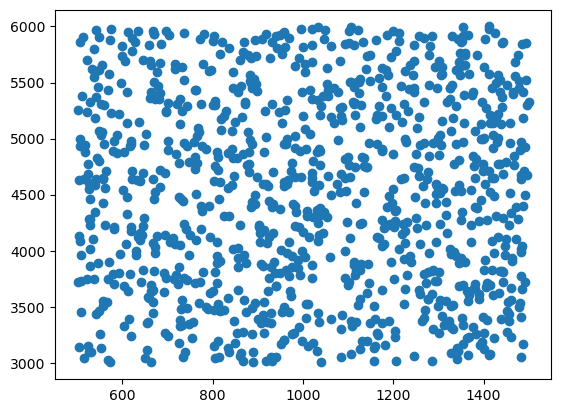

In [61]:

# Visualize the data
plt.scatter(df['monthly_income'], df['tuition'])
plt.show()


<Axes: >

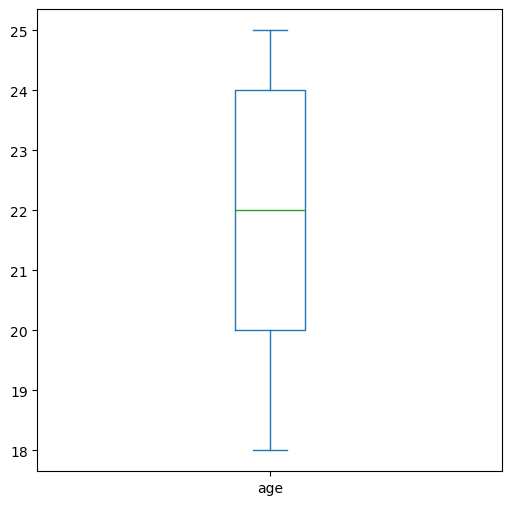

In [62]:
df['age'].plot(kind = "box",
               figsize = (6,6))

<Axes: >

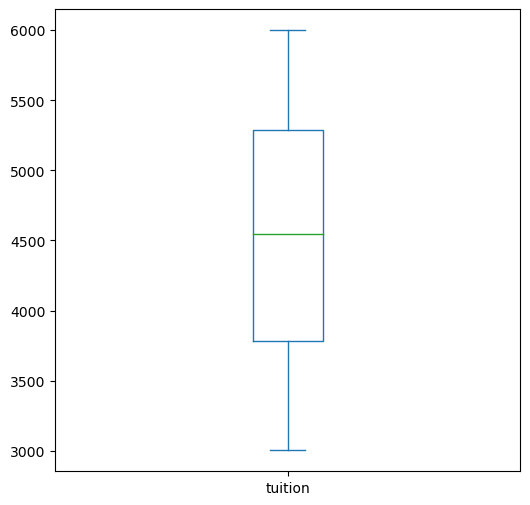

In [63]:
df['tuition'].plot(kind = "box",
               figsize = (6,6))

<Axes: >

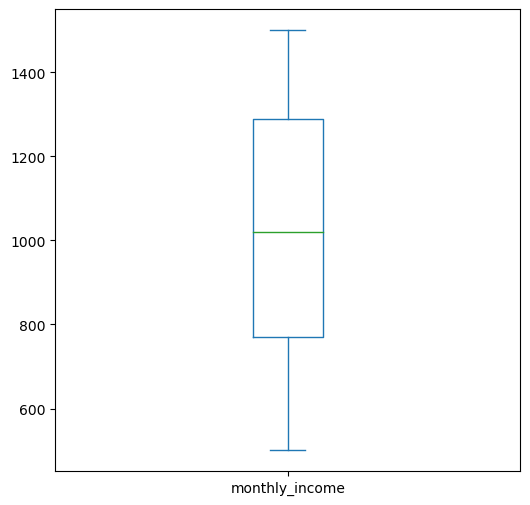

In [64]:
df['monthly_income'].plot(kind = "box",
               figsize = (6,6))

# data description

In [67]:
df.columns

Index(['age', 'gender', 'year_in_school', 'major', 'monthly_income',
       'financial_aid', 'tuition', 'housing', 'food', 'transportation',
       'books_supplies', 'entertainment', 'personal_care', 'technology',
       'health_wellness', 'miscellaneous', 'preferred_payment_method',
       'Age_group', 'total_income', 'major_expenses', 'minor_expenses',
       'total_expenses', 'financially_strained', 'Deficit'],
      dtype='object')

gender            Female  Male  Non-binary
major                                     
Biology               68    77          83
Computer Science      67    68          57
Economics             56    77          71
Engineering           68    71          53
Psychology            64    63          57


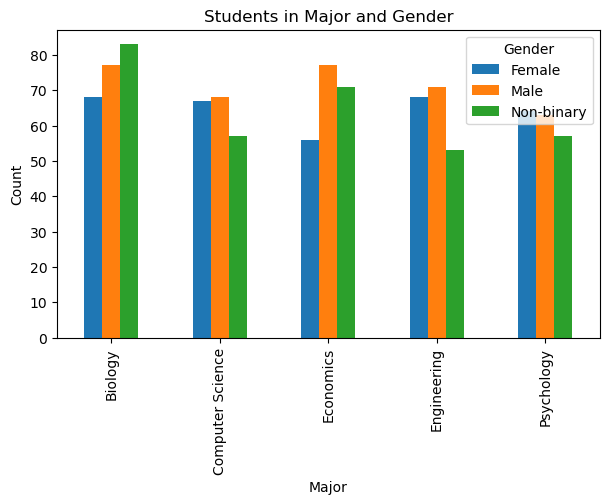

In [168]:
# To get the number of students in each major and their gender
students_in_major_and_gender = df.groupby('major')['gender'].value_counts().unstack()
print(students_in_major_and_gender)

## to visualize the result
students_in_major_and_gender.plot(kind='bar', figsize=(7,4))
plt.title('Students in Major and Gender')
plt.xlabel('Major')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.show()


In [170]:
# to get the number of students based on age_group

age_grouping = df['Age_group'].value_counts()
print(age_grouping)

Age_group
23-25    409
20-22    248
18-20    219
Name: count, dtype: int64


In [75]:
# to get the amount of expenses incured by each major
expenses_by_major = df.groupby('major')['total_expenses'].mean()
print(expenses_by_major)

# from the analysis, Biology seem to incure more expenses that others with engineering and psychology incuring the least

major
Biology             1813.653509
Computer Science    1809.401042
Economics           1765.848039
Engineering         1791.203125
Psychology          1793.592391
Name: total_expenses, dtype: float64


In [83]:
# to get the expenses incured by student in various levels

expenses_by_yearinschool= df.groupby('year_in_school')['total_expenses'].mean()
expenses_by_yearinschoolv = (expenses_by_yearinschool).sort_values(ascending=False)
print(expenses_by_yearinschoolv)


# from the analysis, Senior students incure more expenses that others followed by freshmen.
# sophomore students tend to spend less than others.


year_in_school
Senior       1816.157480
Freshman     1812.948617
Junior       1789.874494
Sophomore    1760.178862
Name: total_expenses, dtype: float64


In [55]:
# to get the income of each age group

age_group_income = df.groupby('Age_group')['total_income'].mean().sort_values(ascending=False)

print(age_group_income)

# from the above, 23-25 aged students get more income with the 18-20 being the least. 

Age_group
23-25    624117
20-22    372519
18-20    339604
Name: total_income, dtype: int64


In [197]:
# To Filter the data to include only engineering students
engineering_students = df[(df['major'] == 'Engineering')]

# Group the data by gender and calculate the count and total income
engineering_gender_income = engineering_students.groupby('gender')[['total_income']].agg(['count', 'mean'])
## to sort the result
engineering_gender_income = engineering_gender_income.sort_values(by=('total_income', 'mean'), ascending=False)

# Print the result
print(engineering_gender_income)


           total_income             
                  count         mean
gender                              
Female               68  1563.441176
Non-binary           53  1559.396226
Male                 71  1506.549296


In [195]:
# to check the amount of expenses incured by various age groups in different majors. 

expenses_agegroup_df = df.groupby(['Age_group', 'major'])['total_expenses'].mean().reset_index()
print(expenses_agegroup_df)

   Age_group             major  total_expenses
0      18-20           Biology     1766.134615
1      18-20  Computer Science     1780.121951
2      18-20         Economics     1745.400000
3      18-20       Engineering     1761.189189
4      18-20        Psychology     1768.285714
5      20-22           Biology     1844.450000
6      20-22  Computer Science     1798.500000
7      20-22         Economics     1783.531915
8      20-22       Engineering     1821.311111
9      20-22        Psychology     1840.608696
10     23-25           Biology     1822.333333
11     23-25  Computer Science     1853.513158
12     23-25         Economics     1756.213483
13     23-25       Engineering     1779.195402
14     23-25        Psychology     1786.042857


   Age_group             major  total_income
2      18-20         Economics   1596.750000
1      18-20  Computer Science   1571.634146
0      18-20           Biology   1570.019231
3      18-20       Engineering   1526.027027
4      18-20        Psychology   1493.734694
8      20-22       Engineering   1559.088889
6      20-22  Computer Science   1541.780000
5      20-22           Biology   1513.283333
9      20-22        Psychology   1503.782609
7      20-22         Economics   1389.361702
12     23-25         Economics   1545.696629
13     23-25       Engineering   1544.436782
14     23-25        Psychology   1533.328571
10     23-25           Biology   1509.149425
11     23-25  Computer Science   1494.144737


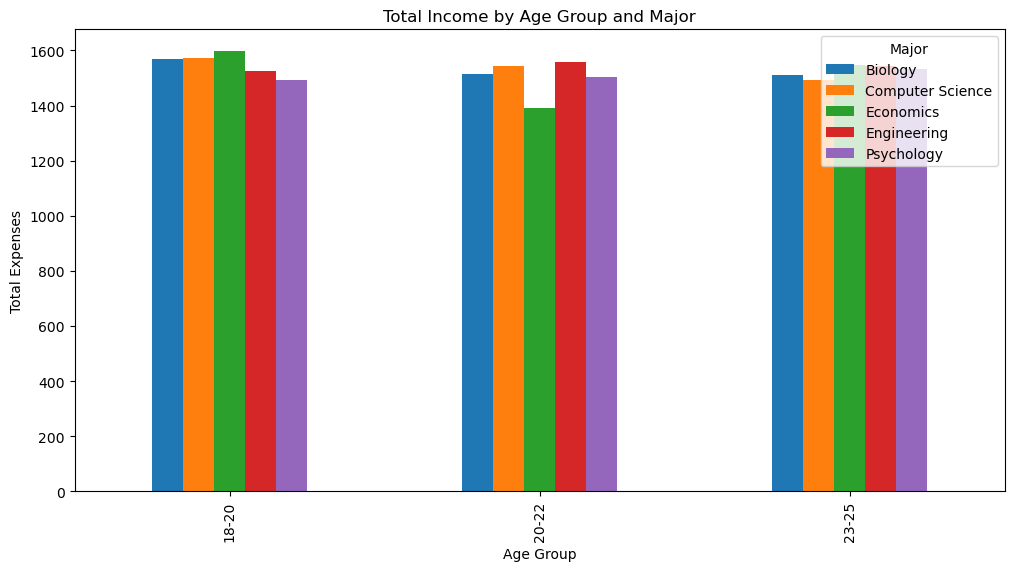

In [198]:
# income by age group and major
income_df = df.groupby(['Age_group', 'major'])['total_income'].mean().reset_index()

# Sort the DataFrame by Age_group and then by total_income
income_df = income_df.sort_values(by=['Age_group', 'total_income'], ascending=[True, False])
print(income_df)

# to display the result
pivot_df = income_df.pivot(index='Age_group', columns='major', values='total_income')
pivot_df.plot(kind='bar', figsize=(12,6))
plt.title('Total Income by Age Group and Major')
plt.xlabel('Age Group')
plt.ylabel('Total Expenses')
plt.legend(title='Major')
plt.show()



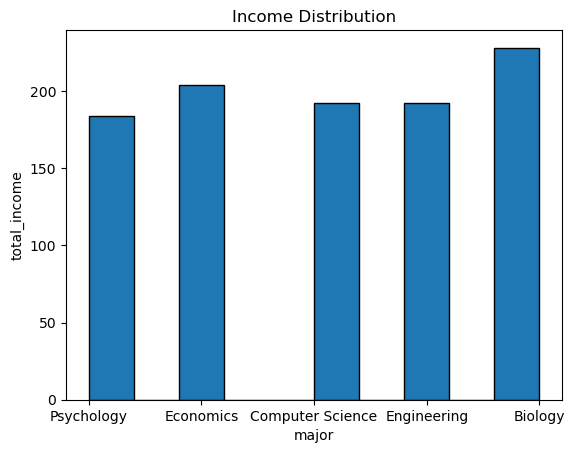

In [82]:
plt.hist(df['major'], bins=10, edgecolor='black')

plt.title('Income Distribution')
plt.xlabel('major')
plt.ylabel('total_income')

plt.show()`

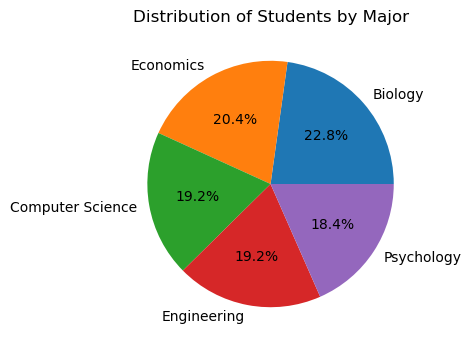

In [73]:
# to get the total number of students in each major
major_counts = df['major'].value_counts()

# Create a pie chart
plt.figure(figsize=(4,4))
plt.pie(major_counts, labels=major_counts.index, autopct='%1.1f%%')
plt.title('Distribution of Students by Major')
plt.show()


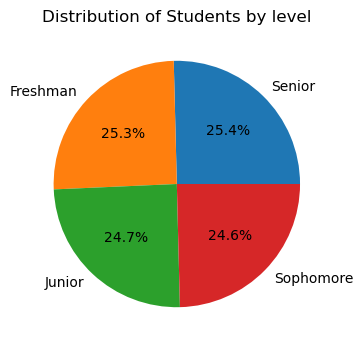

In [60]:
# to get the total number of students in each level or year
level = df['year_in_school'].value_counts()

# Create a pie chart
plt.figure(figsize=(4,4))
plt.pie(level, labels=level.index, autopct='%1.1f%%')
plt.title('Distribution of Students by level')
plt.show()


In [94]:
df.to_csv('student_spending_ready.csv', index=True)


In [46]:
df.columns

Index(['age', 'gender', 'year_in_school', 'major', 'monthly_income',
       'financial_aid', 'tuition', 'housing', 'food', 'transportation',
       'books_supplies', 'entertainment', 'personal_care', 'technology',
       'health_wellness', 'miscellaneous', 'preferred_payment_method',
       'Age_group', 'total_income', 'major_expenses', 'minor_expenses',
       'total_expenses', 'financially_strained', 'Deficit'],
      dtype='object')

# Analysis and visualizations 

              major      tuition
0           Biology  4457.035088
1  Computer Science  4553.989583
2         Economics  4504.955882
3       Engineering  4443.098958
4        Psychology  4661.625000


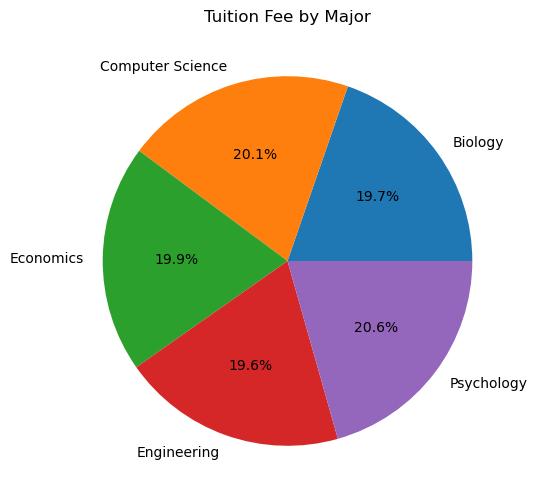

In [171]:
# to get the amount of tuition fee paid by both the different majors
tuition_by_major = df.groupby('major')['tuition'].mean().reset_index()

print(tuition_by_major)
# Create a pie chart
plt.figure(figsize=(6,6))
plt.pie(tuition_by_major['tuition'], labels=tuition_by_major['major'], autopct='%1.1f%%')
plt.title('Tuition Fee by Major')
plt.show()

              major  total_expenses
0           Biology     1813.653509
1  Computer Science     1809.401042
2         Economics     1765.848039
3       Engineering     1791.203125
4        Psychology     1793.592391


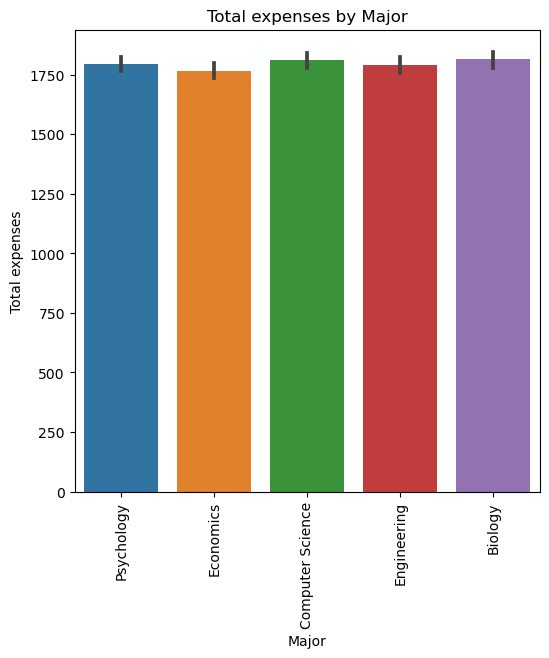

In [173]:
# to get the total expenses of each major
total_expenses_by_major = df.groupby('major')['total_expenses'].mean().reset_index()

print(total_expenses_by_major)

# Total expenses by major
plt.figure(figsize=(6,6))
sns.barplot(x='major', y='total_expenses', data=df)
plt.title('Total expenses by Major')
plt.xlabel('Major')
plt.ylabel('Total expenses')
plt.xticks(rotation=90)
plt.show()

   Age_group             major  total_expenses
0      18-20           Biology     1766.134615
1      18-20  Computer Science     1780.121951
2      18-20         Economics     1745.400000
3      18-20       Engineering     1761.189189
4      18-20        Psychology     1768.285714
5      20-22           Biology     1844.450000
6      20-22  Computer Science     1798.500000
7      20-22         Economics     1783.531915
8      20-22       Engineering     1821.311111
9      20-22        Psychology     1840.608696
10     23-25           Biology     1822.333333
11     23-25  Computer Science     1853.513158
12     23-25         Economics     1756.213483
13     23-25       Engineering     1779.195402
14     23-25        Psychology     1786.042857


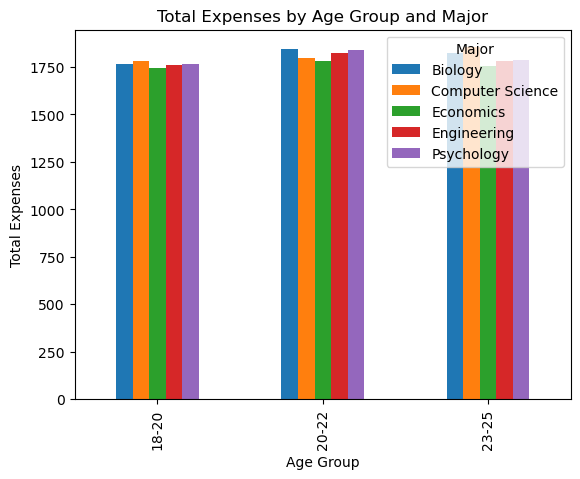

In [182]:
# to check the amount of expenses incured by various age groups in different majors. 

expenses_df = df.groupby(['Age_group', 'major'])['total_expenses'].mean().reset_index()

print(expenses_df)
# to visualize

expenses_df.pivot(index='Age_group', columns='major', values='total_expenses').plot(kind='bar')
plt.title('Total Expenses by Age Group and Major')
plt.xlabel('Age Group')
plt.ylabel('Total Expenses')
plt.legend(title='Major')
plt.show()


   Age_group             major  total_income
0      18-20           Biology   1570.019231
1      18-20  Computer Science   1571.634146
2      18-20         Economics   1596.750000
3      18-20       Engineering   1526.027027
4      18-20        Psychology   1493.734694
5      20-22           Biology   1513.283333
6      20-22  Computer Science   1541.780000
7      20-22         Economics   1389.361702
8      20-22       Engineering   1559.088889
9      20-22        Psychology   1503.782609
10     23-25           Biology   1509.149425
11     23-25  Computer Science   1494.144737
12     23-25         Economics   1545.696629
13     23-25       Engineering   1544.436782
14     23-25        Psychology   1533.328571


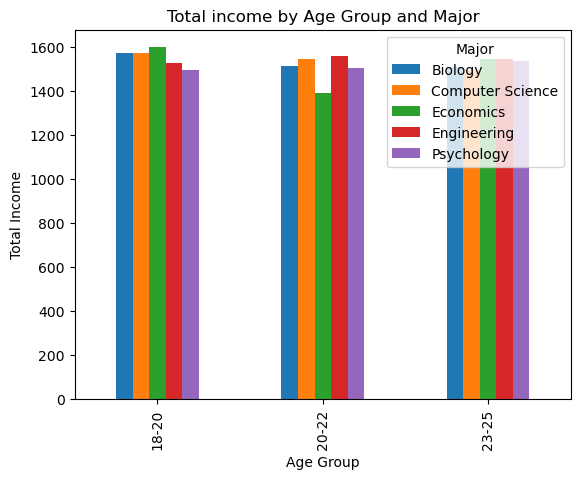

In [184]:
# to check the income of various age groups in different majors. 

income_df = df.groupby(['Age_group', 'major'])['total_income'].mean().reset_index()

print(income_df)
# to visualize

income_df.pivot(index='Age_group', columns='major', values='total_income').plot(kind='bar')
plt.title('Total income by Age Group and Major')
plt.xlabel('Age Group')
plt.ylabel('Total Income')
plt.legend(title='Major')
plt.show()


               major      gender  total_income
0            Biology      Female   1505.382353
1            Biology        Male   1554.259740
2            Biology  Non-binary   1501.843373
3   Computer Science      Female   1523.253731
4   Computer Science        Male   1558.911765
5   Computer Science  Non-binary   1510.368421
6          Economics      Female   1550.196429
7          Economics        Male   1491.285714
8          Economics  Non-binary   1539.084507
9        Engineering      Female   1563.441176
10       Engineering        Male   1506.549296
11       Engineering  Non-binary   1559.396226
12        Psychology      Female   1499.453125
13        Psychology        Male   1527.888889
14        Psychology  Non-binary   1500.087719


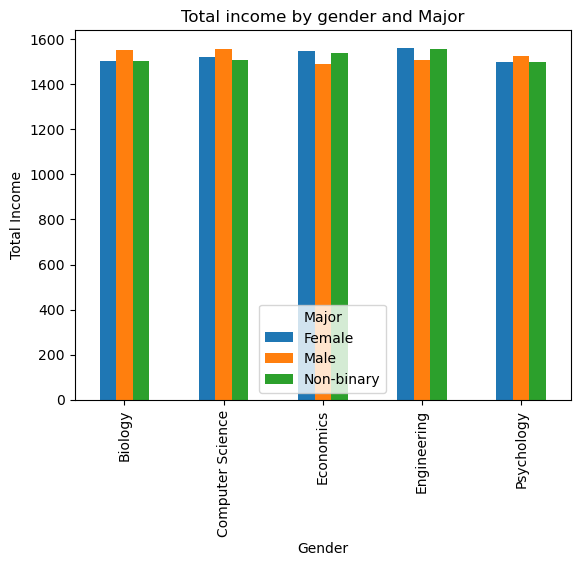

In [177]:
# Total income by each gender in the various major
INCOME_df = df.groupby(['major', 'gender'])['total_income'].mean().reset_index()

print(INCOME_df)
# to visualize
INCOME_df.pivot(index='major', columns='gender', values='total_income').plot(kind='bar')
plt.title('Total income by gender and Major')
plt.xlabel('Gender')
plt.ylabel('Total Income')
plt.legend(title='Major')
plt.show()

In [178]:
# total income by gender 
income_gd = df.groupby('gender')['total_income'].mean()
print(income_gd)

#to visualize the result
income_gd.plot

gender
Female        1527.907121
Male          1527.345506
Non-binary    1520.785047
Name: total_income, dtype: float64


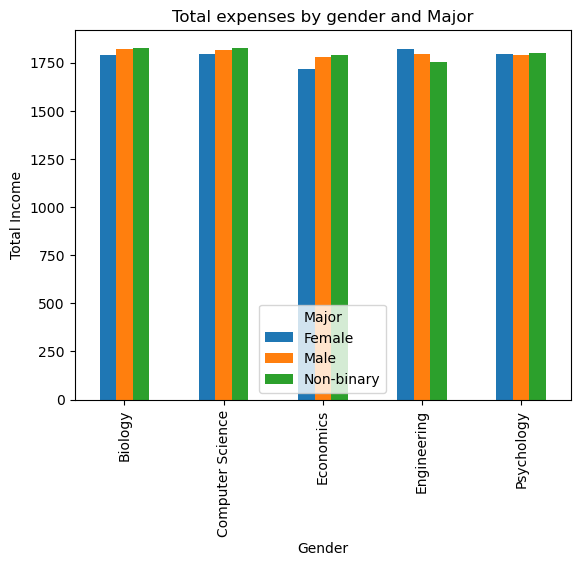

In [179]:
expenses_df = df.groupby(['major', 'gender'])['total_expenses'].mean().reset_index()

# to visualize

expenses_df.pivot(index='major', columns='gender', values='total_expenses').plot(kind='bar')
plt.title('Total expenses by gender and Major')
plt.xlabel('Gender')
plt.ylabel('Total Income')
plt.legend(title='Major')
plt.show()

              major  total_income
0           Biology   1520.600877
1  Computer Science   1532.057292
2         Economics   1524.093137
3       Engineering   1541.286458
4        Psychology   1509.385870


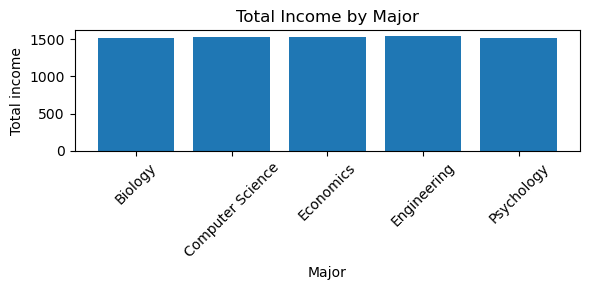

In [193]:
# Group by 'major' and calculate the sum of 'Total_income'
total_income_by_majors = df.groupby('major')['total_income'].mean().reset_index()
print(total_income_by_majors)

# Plot the bar chart
plt.figure(figsize=(6,3))
plt.bar(total_income_by_majors['major'], total_income_by_majors['total_income'])
plt.xlabel('Major')
plt.ylabel('Total income')
plt.title('Total Income by Major')
plt.xticks(rotation=45)  
plt.tight_layout()  # 
plt.show()

In [85]:
student_counts = df.groupby(['major', 'gender']).size().reset_index(name='count')
print(student_counts)

               major      gender  count
0            Biology      Female     68
1            Biology        Male     77
2            Biology  Non-binary     83
3   Computer Science      Female     67
4   Computer Science        Male     68
5   Computer Science  Non-binary     57
6          Economics      Female     56
7          Economics        Male     77
8          Economics  Non-binary     71
9        Engineering      Female     68
10       Engineering        Male     71
11       Engineering  Non-binary     53
12        Psychology      Female     64
13        Psychology        Male     63
14        Psychology  Non-binary     57


In [29]:
df.columns

Index(['age', 'gender', 'year_in_school', 'major', 'monthly_income',
       'financial_aid', 'tuition', 'housing', 'food', 'transportation',
       'books_supplies', 'entertainment', 'personal_care', 'technology',
       'health_wellness', 'miscellaneous', 'preferred_payment_method',
       'Age_group', 'total_income', 'major_expenses', 'minor_expenses',
       'total_expenses', 'financially_strained', 'Deficit'],
      dtype='object')

  Age_group  total_expenses
0     18-20     1764.611872
1     20-22     1818.729839
2     23-25     1798.352078


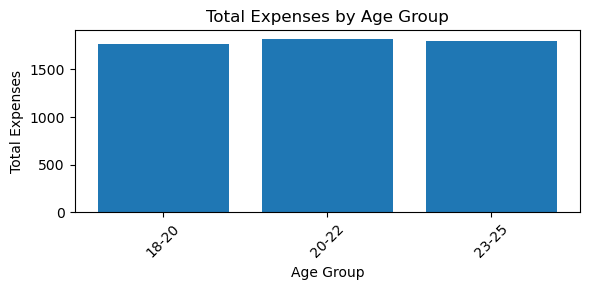

In [181]:
# Group by 'Age_group' and calculate the sum of 'Total_expenses'
total_expenses_by_age_group = df.groupby('Age_group')['total_expenses'].mean().reset_index()

print(total_expenses_by_age_group)
# Plot the bar chart
plt.figure(figsize=(6,3))
plt.bar(total_expenses_by_age_group['Age_group'], total_expenses_by_age_group['total_expenses'])
plt.xlabel('Age Group')
plt.ylabel('Total Expenses')
plt.title('Total Expenses by Age Group')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Ensure labels fit within the plot area
plt.show()


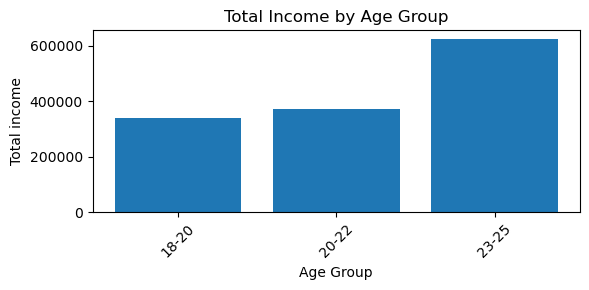

In [88]:
# Group by 'Age_group' and calculate the sum of 'Total_income'
total_income_by_age_group = df.groupby('Age_group')['total_income'].sum().reset_index()

# Plot the bar chart
plt.figure(figsize=(6,3))
plt.bar(total_expenses_by_age_group['Age_group'], total_income_by_age_group['total_income'])
plt.xlabel('Age Group')
plt.ylabel('Total income')
plt.title('Total Income by Age Group')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Ensure labels fit within the plot area
plt.show()


  year_in_school  total_expenses
0       Freshman     1812.948617
1         Junior     1789.874494
2         Senior     1816.157480
3      Sophomore     1760.178862


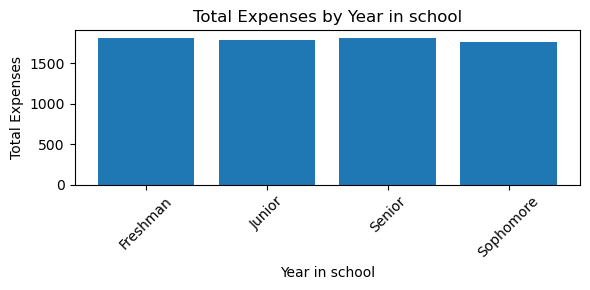

In [186]:
# Group by 'Year in school' and calculate the mean of 'Total_expenses'
total_expenses_by_year_school = df.groupby('year_in_school')['total_expenses'].mean().reset_index()
print(total_expenses_by_year_school)
# Plot the bar chart
plt.figure(figsize=(6,3))
plt.bar(total_expenses_by_year_school['year_in_school'],total_expenses_by_year_school['total_expenses'])
plt.xlabel('Year in school')
plt.ylabel('Total Expenses')
plt.title('Total Expenses by Year in school')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Ensure labels fit within the plot area
plt.show()


  year_in_school  total_income
0       Freshman   1561.407115
1         Junior   1521.344130
2         Senior   1526.952756
3      Sophomore   1490.922764


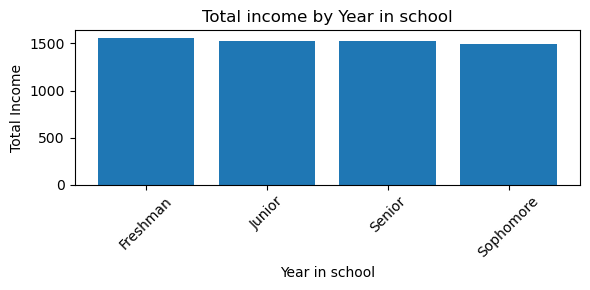

In [188]:
# Group by 'Year in school' and calculate the mean of 'Total_income'
total_income_by_year_school = df.groupby('year_in_school')['total_income'].mean().reset_index()
print(total_income_by_year_school)
# Plot the bar chart
plt.figure(figsize=(6,3))
plt.bar(total_expenses_by_year_school['year_in_school'],total_income_by_year_school['total_income'])
plt.xlabel('Year in school')
plt.ylabel('Total Income')
plt.title('Total income by Year in school')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Ensure labels fit within the plot area
plt.show()


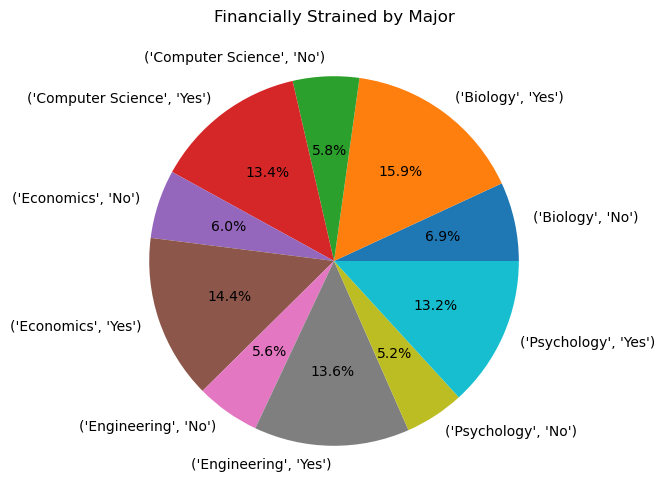

In [94]:
# Group by 'major' and 'financially_strained', and count the values
grouped_df = df.groupby(['major', 'financially_strained']).size()

# Create a pie chart
plt.figure(figsize=(8,6))
plt.pie(grouped_df, labels = grouped_df.index, autopct='%1.1f%%')
plt.title('Financially Strained by Major')
plt.show()


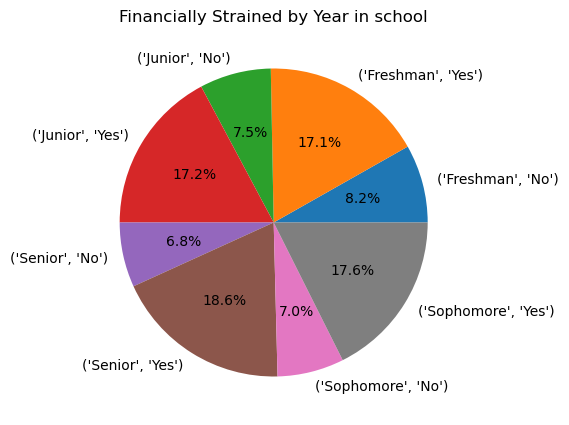

In [92]:
# Group by 'year_in_school' and 'financially_strained', and count the values
grouped_df = df.groupby(['year_in_school', 'financially_strained']).size()

# Create a pie chart
plt.figure(figsize=(8,5))
plt.pie(grouped_df, labels = grouped_df.index, autopct='%1.1f%%')
plt.title('Financially Strained by Year in school')
plt.show()

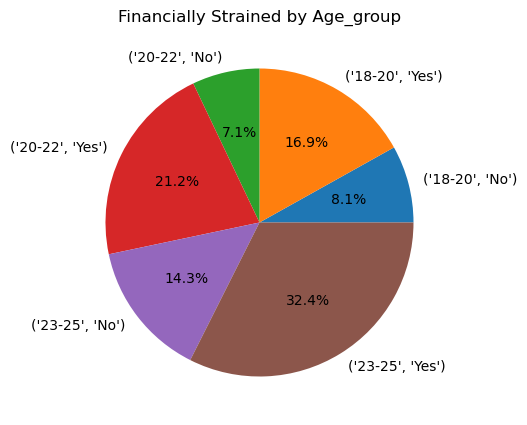

In [90]:
# Group by 'major' and 'financially_strained', and count the values
grouped_df = df.groupby(['Age_group', 'financially_strained']).size()

# Create a pie chart
plt.figure(figsize=(8,5))
plt.pie(grouped_df, labels = grouped_df.index, autopct='%1.1f%%')
plt.title('Financially Strained by Age_group')
plt.show()

gender      financially_strained
Female      No                      104
            Yes                     219
Male        No                      107
            Yes                     249
Non-binary  No                       84
            Yes                     237
dtype: int64


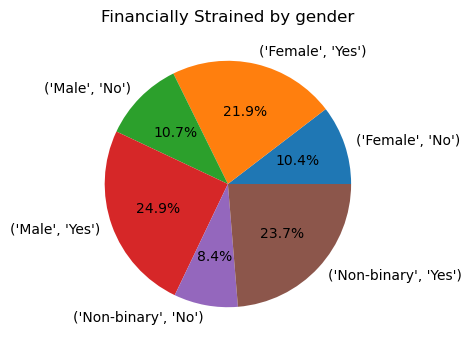

In [97]:
gender_df = df.groupby(['gender', 'financially_strained']).size()
print(gender_df)
# Create a pie chart
plt.figure(figsize=(7,4))
plt.pie(gender_df, labels = gender_df.index, autopct='%1.1f%%')
plt.title('Financially Strained by gender')
plt.show()

In [74]:
df.head(6)

,age,gender,year_in_school,major,monthly_income,financial_aid,tuition,housing,food,transportation,...,health_wellness,miscellaneous,preferred_payment_method,Age_group,total_income,major_expenses,minor_expenses,total_expenses,financially_strained,Deficit
0,19,Non-binary,Freshman,Psychology,958,270,5939,709,296,123,...,127,72,Credit/Debit Card,18-20,1228,1128,640,1768,Yes,-540
1,24,Female,Junior,Economics,1006,875,4908,557,365,85,...,129,68,Credit/Debit Card,23-25,1881,1007,841,1848,No,33
2,24,Non-binary,Junior,Economics,734,928,3051,666,220,137,...,112,133,Cash,23-25,1662,1023,736,1759,Yes,-97
3,23,Female,Senior,Computer Science,617,265,4935,652,289,114,...,105,55,Mobile Payment App,23-25,882,1055,675,1730,Yes,-848
4,20,Female,Senior,Computer Science,810,522,3887,825,372,168,...,71,104,Credit/Debit Card,18-20,1332,1365,576,1941,Yes,-609
5,25,Non-binary,Sophomore,Computer Science,523,790,3151,413,386,122,...,108,99,Mobile Payment App,23-25,1313,921,683,1604,Yes,-291


                            total_income        
                                   count     sum
major            gender                         
Biology          Non-binary           83  124653
                 Male                 77  119678
Economics        Male                 77  114829
                 Non-binary           71  109275
Engineering      Male                 71  106965
                 Female               68  106314
Computer Science Male                 68  106006
Biology          Female               68  102366
Computer Science Female               67  102058
Psychology       Male                 63   96257
                 Female               64   95965
Economics        Female               56   86811
Computer Science Non-binary           57   86091
Psychology       Non-binary           57   85505
Engineering      Non-binary           53   82648


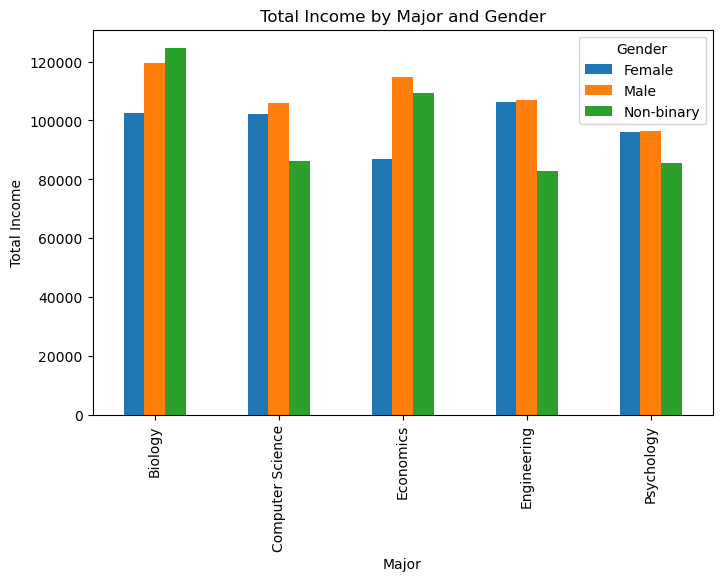

In [61]:
# Group the data by major and gender, and calculate the count and total income
major_gender_income = df.groupby(['major', 'gender'])[['total_income']].agg(['count', 'sum'])

# Sort the result by total income in descending order
major_gender_income = major_gender_income.sort_values(by=('total_income', 'sum'), ascending=False)

# Print the result
print(major_gender_income)

#Plot the data on a bar chart
major_gender_income['total_income', 'sum'].unstack('gender').plot(kind='bar', figsize=(8,5))
plt.title('Total Income by Major and Gender')
plt.xlabel('Major')
plt.ylabel('Total Income')
plt.legend(title='Gender')


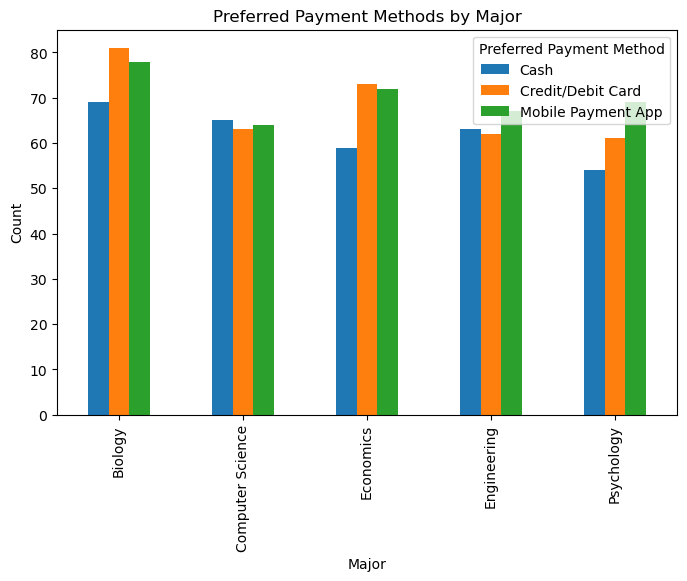

In [126]:
# to get the preferred payment  method by major
payment_gd_df = df.groupby(['preferred_payment_method', 'major']).size().reset_index(name='count')


# to display result 

# Pivot the data to prepare for plotting
pivot_df = payment_gd_df.pivot(index='major', columns='preferred_payment_method', values='count')

# Plot the data
pivot_df.plot(kind='bar', figsize=(8,5))
plt.title('Preferred Payment Methods by Major')
plt.xlabel('Major')
plt.ylabel('Count')
plt.legend(title='Preferred Payment Method')
plt.show()


preferred_payment_method
Mobile Payment App    350
Credit/Debit Card     340
Cash                  310
Name: count, dtype: int64


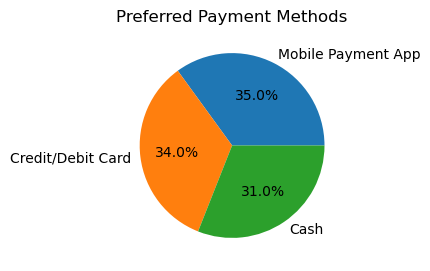

In [122]:
# to get the preferred payment method
payment_df = df['preferred_payment_method'].value_counts()
print(payment_df)

# to display the result

plt.figure(figsize=(5,3))
plt.pie(payment_df, labels=payment_df.index, autopct='%1.1f%%')
plt.title('Preferred Payment Methods')
plt.show()


  Age_group  major_expenses  minor_expenses
0     18-20          227357          159093
1     20-22          271081          179964
2     23-25          440315          295211


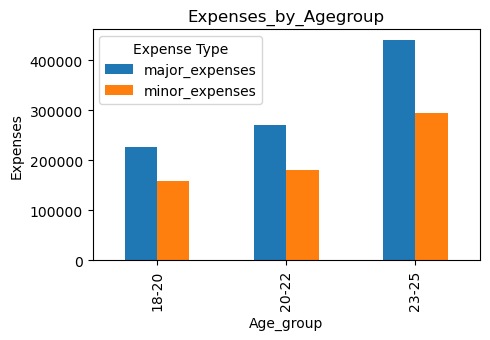

In [142]:
## major and minor expenses by Age_group
expenses_by_Agegroup = df.pivot_table(index='Age_group', values=['major_expenses', 'minor_expenses'], aggfunc='sum').reset_index()

# Print the results
print(expenses_by_Agegroup)

# to show the result in a bar plot
expenses_by_Agegroup.plot(kind='bar', x='Age_group', figsize=(5,3))

# Set title and labels
plt.title('Expenses_by_Agegroup')
plt.xlabel('Age_group')
plt.ylabel('Expenses')
plt.legend(title='Expense Type')

# Show the plot
plt.show()

  preferred_payment_method  major_expenses  minor_expenses
0                     Cash          330420          226103
1        Credit/Debit Card          367161          248191
2       Mobile Payment App          375704          247504


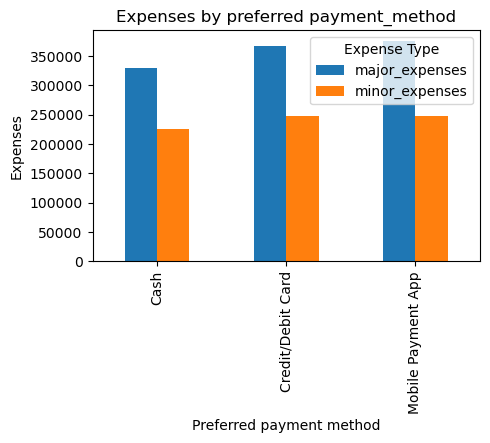

In [140]:
# major and minor expenses by preferred payment method
expenses_by_preferred_payment_method= df.pivot_table(index='preferred_payment_method', values=['major_expenses', 'minor_expenses'], aggfunc='sum').reset_index()

# Print the results
print(expenses_by_preferred_payment_method)

# to show the result in a bar plot
expenses_by_preferred_payment_method.plot(kind='bar', x='preferred_payment_method', figsize=(5,3))

# Set title and labels
plt.title('Expenses by preferred payment_method')
plt.xlabel('Preferred payment method')
plt.ylabel('Expenses')
plt.legend(title='Expense Type')

# Show the plot
plt.show()


  year_in_school  major_expenses  minor_expenses
0       Freshman          273674          185002
1         Junior          265425          176674
2         Senior          277106          184198
3      Sophomore          257080          175924


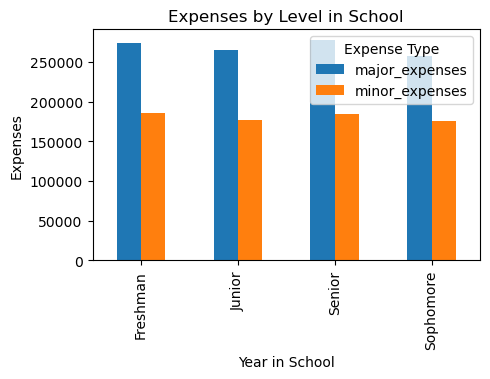

In [138]:
# major and minor expenses by level in school
expenses_by_level = df.pivot_table(index='year_in_school', values=['major_expenses', 'minor_expenses'], aggfunc='sum').reset_index()

# Print the results
print(expenses_by_level)

# to show the result in a bar plot
expenses_by_level.plot(kind='bar', x='year_in_school', figsize=(5,3))

# Set title and labels
plt.title('Expenses by Level in School')
plt.xlabel('Year in School')
plt.ylabel('Expenses')
plt.legend(title='Expense Type')

# Show the plot
plt.show()

In [131]:
df.head(4)

,age,gender,year_in_school,major,monthly_income,financial_aid,tuition,housing,food,transportation,...,health_wellness,miscellaneous,preferred_payment_method,Age_group,total_income,major_expenses,minor_expenses,total_expenses,financially_strained,Deficit
0,19,Non-binary,Freshman,Psychology,958,270,5939,709,296,123,...,127,72,Credit/Debit Card,18-20,1228,1128,640,1768,Yes,-540
1,24,Female,Junior,Economics,1006,875,4908,557,365,85,...,129,68,Credit/Debit Card,23-25,1881,1007,841,1848,No,33
2,24,Non-binary,Junior,Economics,734,928,3051,666,220,137,...,112,133,Cash,23-25,1662,1023,736,1759,Yes,-97
3,23,Female,Senior,Computer Science,617,265,4935,652,289,114,...,105,55,Mobile Payment App,23-25,882,1055,675,1730,Yes,-848


Age_group       18-20  20-22  23-25
year_in_school                     
Freshman           58     63     96
Junior             63     57    105
Senior             56     63     99
Sophomore          42     65    109


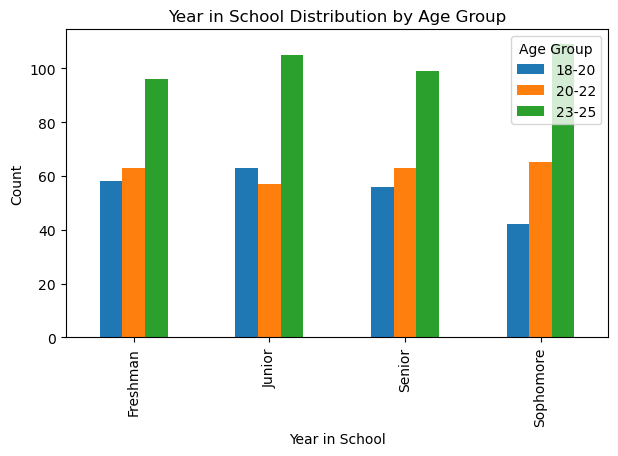

In [155]:
# year in school distribution by age_group
# Create a pivot table
year_in_school_distribution = df.pivot_table(index='year_in_school', columns='Age_group', values='financially_strained', aggfunc='count').fillna(0)

# Print the results
print(year_in_school_distribution)

# to show result in a plot

year_in_school_distribution.plot(kind='bar', figsize=(7,4))

# Set title and labels
plt.title('Year in School Distribution by Age Group')
plt.xlabel('Year in School')
plt.ylabel('Count')
plt.legend(title='Age Group')

# Show the plot
plt.show()


In [148]:
df.columns

Index(['age', 'gender', 'year_in_school', 'major', 'monthly_income',
       'financial_aid', 'tuition', 'housing', 'food', 'transportation',
       'books_supplies', 'entertainment', 'personal_care', 'technology',
       'health_wellness', 'miscellaneous', 'preferred_payment_method',
       'Age_group', 'total_income', 'major_expenses', 'minor_expenses',
       'total_expenses', 'financially_strained', 'Deficit'],
      dtype='object')

0.037049722477874115


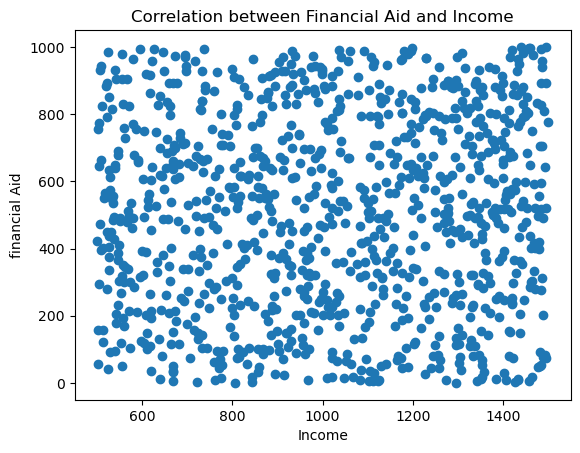

In [164]:
# to Calculate the correlation between financial aid and income
correlation = df['financial_aid'].corr(df['monthly_income'])

# Print the result
print(correlation)


# to visualize the reult using a scatter plot
plt.scatter(df['monthly_income'], df['financial_aid'])

# Set title and labels
plt.title('Correlation between Financial Aid and Income')
plt.xlabel('Income')
plt.ylabel('financial Aid')

# Show the plot
plt.show()
